In [5]:
# Input file paths
prediction_prob_file = "/home/tsukagoshitoshihiro/workspace/ICASSP/Semi_supervise/semi_SL_output/1st_pseudo_label_source/WavLM-base+GRU_309_frame_probabilities.txt"
ground_truth_file = "/home/tsukagoshitoshihiro/workspace/ICASSP/Semi_supervise/dataset/exist_label/309.txt"



Calculating scores for each threshold...
Calculation complete. Plotting graph...


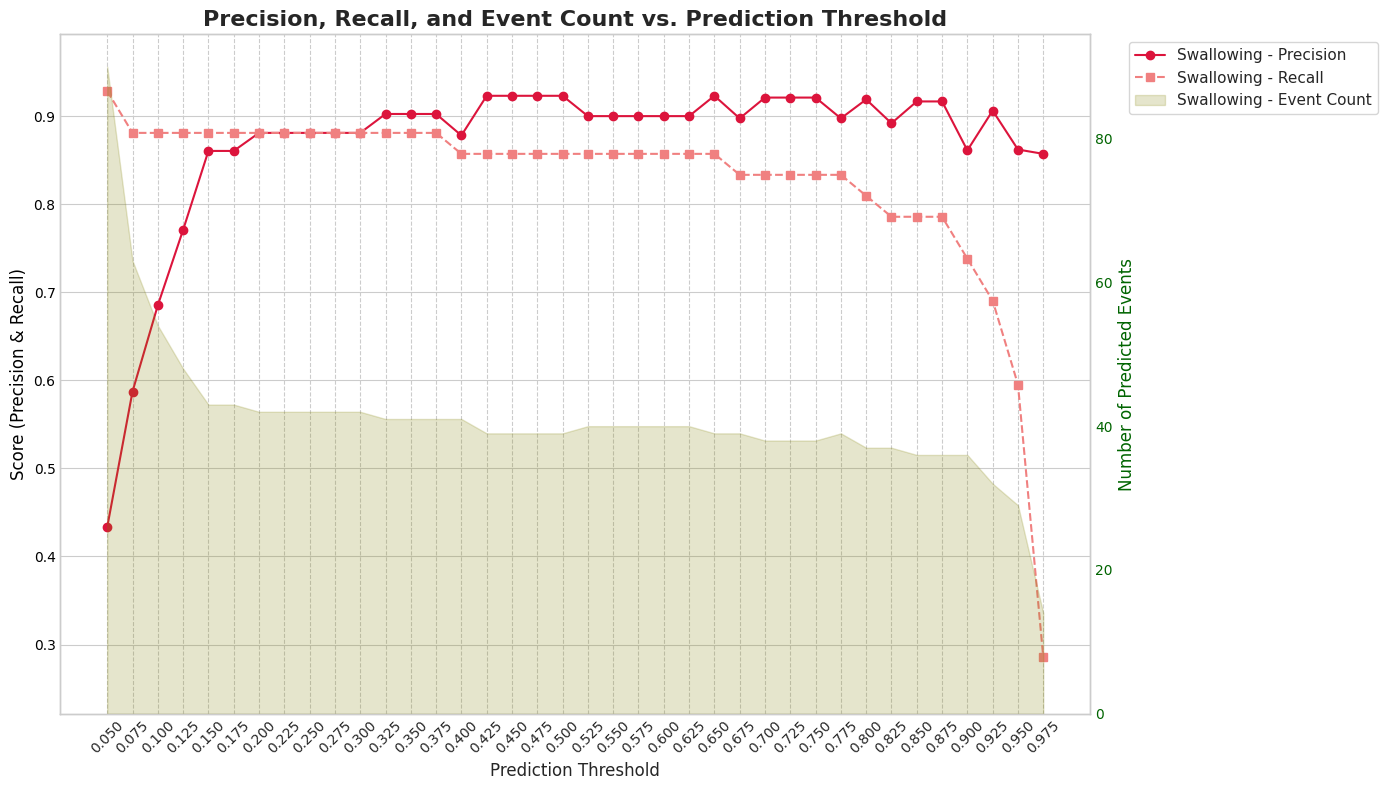

In [6]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Evaluation parameters
iou_thresholds = {
    "swallowing": 0.1
}
labels_to_evaluate = {
    "swallowing": "sw"
}

# Time window for evaluation (in seconds)
EVAL_START_SEC = 10 * 60  # 10 minutes
EVAL_END_SEC = 30 * 60    # 30 minutes

# --- 2. Utility Functions (Unchanged) ---

def convert_to_segments(binary_series: np.ndarray, times: np.ndarray) -> list:
    segments = []
    in_segment = False
    start_time = 0.0
    padded_series = np.pad(binary_series, (0, 1), 'constant', constant_values=0)
    padded_times = np.pad(times, (0, 1), 'edge')

    for i, value in enumerate(padded_series):
        if value > 0 and not in_segment:
            in_segment = True
            start_time = padded_times[i]
        elif value == 0 and in_segment:
            in_segment = False
            end_time = padded_times[i]
            if start_time < end_time:
                segments.append((start_time, end_time))
    return segments

def calculate_iou(seg1: tuple, seg2: tuple) -> float:
    start1, end1 = seg1
    start2, end2 = seg2
    intersection_start = max(start1, start2)
    intersection_end = min(end1, end2)
    intersection = max(0, intersection_end - intersection_start)
    union = (end1 - start1) + (end2 - start2) - intersection
    return intersection / union if union > 0 else 0

def evaluate_performance(gt_segments: list, pred_segments: list, iou_threshold: float) -> tuple:
    if not gt_segments or not pred_segments:
        tp, fp, fn = 0, len(pred_segments), len(gt_segments)
    else:
        iou_matrix = np.zeros((len(gt_segments), len(pred_segments)))
        for i, gt_seg in enumerate(gt_segments):
            for j, pred_seg in enumerate(pred_segments):
                iou_matrix[i, j] = calculate_iou(gt_seg, pred_seg)
        matched_gt = np.zeros(len(gt_segments), dtype=bool)
        matched_pred = np.zeros(len(pred_segments), dtype=bool)
        potential_matches = np.where(iou_matrix >= iou_threshold)
        sorted_indices = np.argsort(iou_matrix[potential_matches])[::-1]
        for idx in sorted_indices:
            gt_idx, pred_idx = potential_matches[0][idx], potential_matches[1][idx]
            if not matched_gt[gt_idx] and not matched_pred[pred_idx]:
                matched_gt[gt_idx], matched_pred[pred_idx] = True, True
        tp = np.sum(matched_gt)
        fn = len(gt_segments) - tp
        fp = len(pred_segments) - tp
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    return precision, recall, f1_score, tp, fp, fn

# --- 3. Main Processing ---

try:
    pred_prob_data = pd.read_csv(prediction_prob_file, sep='\t')
    gt_data = pd.read_csv(ground_truth_file, sep='\t', header=None, names=['start_time', 'end_time', 'label'])
except FileNotFoundError as e:
    print(f"Error: Could not find file - {e.filename}")
    exit()

ground_truth_events = {}
for label_long, label_short in labels_to_evaluate.items():
    gt_segs_df = gt_data[gt_data['label'] == label_short]
    all_segments = list(zip(gt_segs_df['start_time'], gt_segs_df['end_time']))
    ground_truth_events[label_long] = [
        seg for seg in all_segments if seg[0] < EVAL_END_SEC and seg[1] > EVAL_START_SEC
    ]

thresholds = np.arange(0.05, 1.0, 0.025)
results = {label: {'precision': [], 'recall': [], 'pred_count': []} for label in labels_to_evaluate.keys()}

print("Calculating scores for each threshold...")
for threshold in thresholds:
    predicted_events = {}
    for label_long in labels_to_evaluate.keys():
        binary_series = (pred_prob_data[label_long] >= threshold).astype(int).values
        all_segments = convert_to_segments(binary_series, pred_prob_data['time'].values)
        predicted_events[label_long] = [
            seg for seg in all_segments if seg[0] < EVAL_END_SEC and seg[1] > EVAL_START_SEC
        ]
    
    for label_long in labels_to_evaluate.keys():
        gt_segs = ground_truth_events[label_long]
        pred_segs = predicted_events[label_long]
        iou_thresh = iou_thresholds[label_long]
        
        precision, recall, _, _, _, _ = evaluate_performance(gt_segs, pred_segs, iou_thresh)
        
        results[label_long]['precision'].append(precision)
        results[label_long]['recall'].append(recall)
        results[label_long]['pred_count'].append(len(pred_segs))

print("Calculation complete. Plotting graph...")

# --- 4. Plotting ---
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax1 = plt.subplots(figsize=(14, 8))

# --- Left Y-axis (ax1) for Precision & Recall ---
ax1.set_xlabel('Prediction Threshold', fontsize=12)
ax1.set_ylabel('Score (Precision & Recall)', fontsize=12, color='black')
ax1.tick_params(axis='y', labelcolor='black')
ax1.set_xticks(thresholds)
ax1.tick_params(axis='x', rotation=45)

ax1.plot(thresholds, results['swallowing']['precision'], 'o-', label='Swallowing - Precision', color='crimson')
ax1.plot(thresholds, results['swallowing']['recall'], 's--', label='Swallowing - Recall', color='lightcoral')

all_scores = []
for label_data in results.values():
    all_scores.extend(label_data['precision'])
    all_scores.extend(label_data['recall'])
if all_scores:
    min_score, max_score = min(all_scores), max(all_scores)
    padding = (max_score - min_score) * 0.1
    ax1.set_ylim(max(0.0, min_score - padding), min(1.05, max_score + padding))
else:
    ax1.set_ylim(0.0, 1.05)


# --- Right Y-axis (ax2) for Event Count ---
ax2 = ax1.twinx()
ax2.set_ylabel('Number of Predicted Events', fontsize=12, color='darkgreen')
ax2.tick_params(axis='y', labelcolor='darkgreen')

# ★★★ Change alpha from 0.3 to 0.2 to make it more transparent ★★★

ax2.fill_between(thresholds, results['swallowing']['pred_count'], 
                 label='Swallowing - Event Count', 
                 color='olive', 
                 alpha=0.2)

ax2.set_ylim(bottom=0)


# --- Overall Graph Adjustments ---
ax1.set_title('Precision, Recall, and Event Count vs. Prediction Threshold', fontsize=16, weight='bold')
ax1.grid(True, which='major', linestyle='--', axis='x')
ax2.grid(False)

# Combine legends and place outside
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, 
           loc='upper left', 
           bbox_to_anchor=(1.03, 1.0),
           fontsize=11,
           frameon=True)

fig.tight_layout()
plt.show()

Calculating scores for each threshold...
Calculation complete. Plotting graph...


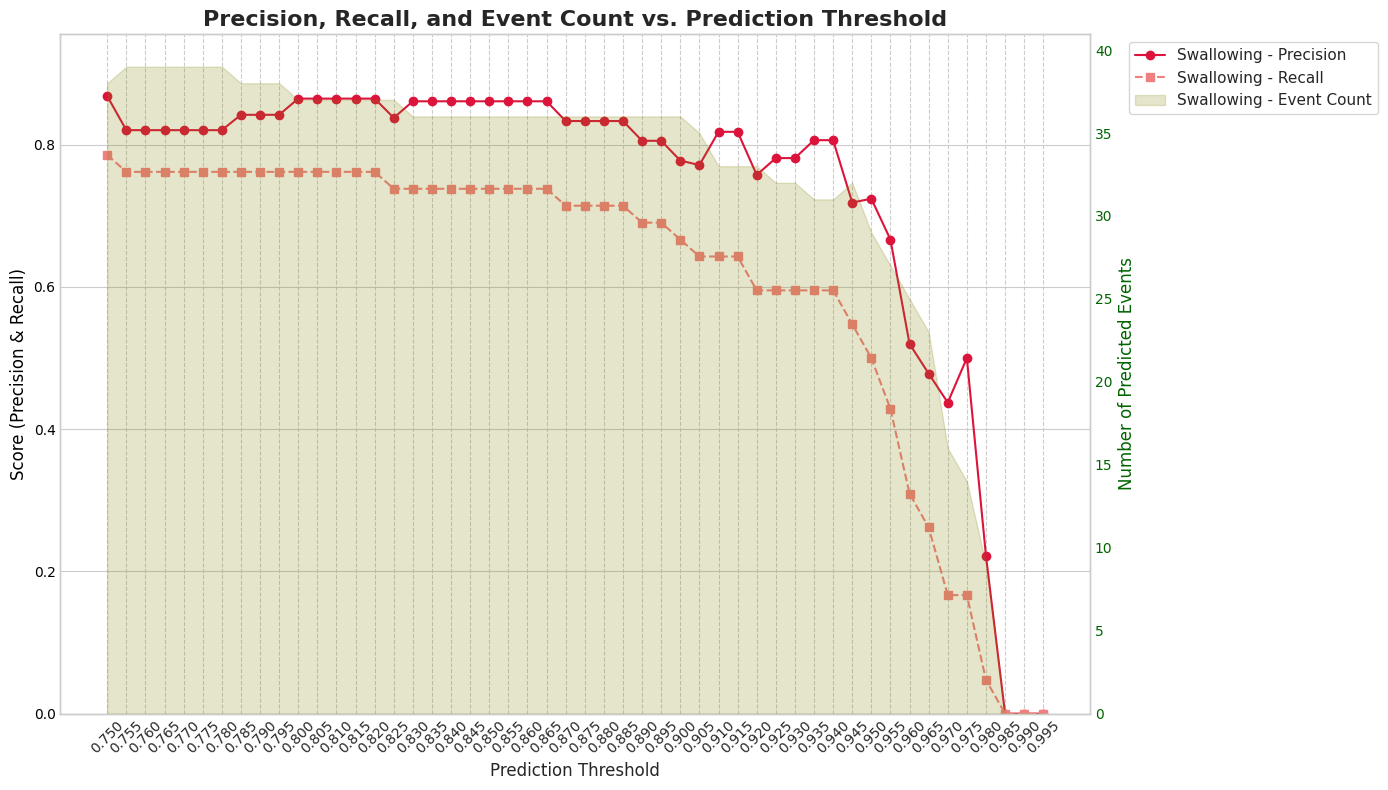

In [7]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Evaluation parameters
iou_thresholds = {
    "swallowing": 0.3
}
labels_to_evaluate = {
    "swallowing": "sw"
}

# Time window for evaluation (in seconds)
EVAL_START_SEC = 10 * 60  # 10 minutes
EVAL_END_SEC = 30 * 60    # 30 minutes

# --- 2. Utility Functions (Unchanged) ---

def convert_to_segments(binary_series: np.ndarray, times: np.ndarray) -> list:
    segments = []
    in_segment = False
    start_time = 0.0
    padded_series = np.pad(binary_series, (0, 1), 'constant', constant_values=0)
    padded_times = np.pad(times, (0, 1), 'edge')

    for i, value in enumerate(padded_series):
        if value > 0 and not in_segment:
            in_segment = True
            start_time = padded_times[i]
        elif value == 0 and in_segment:
            in_segment = False
            end_time = padded_times[i]
            if start_time < end_time:
                segments.append((start_time, end_time))
    return segments

def calculate_iou(seg1: tuple, seg2: tuple) -> float:
    start1, end1 = seg1
    start2, end2 = seg2
    intersection_start = max(start1, start2)
    intersection_end = min(end1, end2)
    intersection = max(0, intersection_end - intersection_start)
    union = (end1 - start1) + (end2 - start2) - intersection
    return intersection / union if union > 0 else 0

def evaluate_performance(gt_segments: list, pred_segments: list, iou_threshold: float) -> tuple:
    if not gt_segments or not pred_segments:
        tp, fp, fn = 0, len(pred_segments), len(gt_segments)
    else:
        iou_matrix = np.zeros((len(gt_segments), len(pred_segments)))
        for i, gt_seg in enumerate(gt_segments):
            for j, pred_seg in enumerate(pred_segments):
                iou_matrix[i, j] = calculate_iou(gt_seg, pred_seg)
        matched_gt = np.zeros(len(gt_segments), dtype=bool)
        matched_pred = np.zeros(len(pred_segments), dtype=bool)
        potential_matches = np.where(iou_matrix >= iou_threshold)
        sorted_indices = np.argsort(iou_matrix[potential_matches])[::-1]
        for idx in sorted_indices:
            gt_idx, pred_idx = potential_matches[0][idx], potential_matches[1][idx]
            if not matched_gt[gt_idx] and not matched_pred[pred_idx]:
                matched_gt[gt_idx], matched_pred[pred_idx] = True, True
        tp = np.sum(matched_gt)
        fn = len(gt_segments) - tp
        fp = len(pred_segments) - tp
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    return precision, recall, f1_score, tp, fp, fn

# --- 3. Main Processing ---

try:
    pred_prob_data = pd.read_csv(prediction_prob_file, sep='\t')
    gt_data = pd.read_csv(ground_truth_file, sep='\t', header=None, names=['start_time', 'end_time', 'label'])
except FileNotFoundError as e:
    print(f"Error: Could not find file - {e.filename}")
    exit()

ground_truth_events = {}
for label_long, label_short in labels_to_evaluate.items():
    gt_segs_df = gt_data[gt_data['label'] == label_short]
    all_segments = list(zip(gt_segs_df['start_time'], gt_segs_df['end_time']))
    ground_truth_events[label_long] = [
        seg for seg in all_segments if seg[0] < EVAL_END_SEC and seg[1] > EVAL_START_SEC
    ]

thresholds = np.arange(0.75, 1.0, 0.005)
results = {label: {'precision': [], 'recall': [], 'pred_count': []} for label in labels_to_evaluate.keys()}

print("Calculating scores for each threshold...")
for threshold in thresholds:
    predicted_events = {}
    for label_long in labels_to_evaluate.keys():
        binary_series = (pred_prob_data[label_long] >= threshold).astype(int).values
        all_segments = convert_to_segments(binary_series, pred_prob_data['time'].values)
        predicted_events[label_long] = [
            seg for seg in all_segments if seg[0] < EVAL_END_SEC and seg[1] > EVAL_START_SEC
        ]
    
    for label_long in labels_to_evaluate.keys():
        gt_segs = ground_truth_events[label_long]
        pred_segs = predicted_events[label_long]
        iou_thresh = iou_thresholds[label_long]
        
        precision, recall, _, _, _, _ = evaluate_performance(gt_segs, pred_segs, iou_thresh)
        
        results[label_long]['precision'].append(precision)
        results[label_long]['recall'].append(recall)
        results[label_long]['pred_count'].append(len(pred_segs))

print("Calculation complete. Plotting graph...")

# --- 4. Plotting ---
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax1 = plt.subplots(figsize=(14, 8))

# --- Left Y-axis (ax1) for Precision & Recall ---
ax1.set_xlabel('Prediction Threshold', fontsize=12)
ax1.set_ylabel('Score (Precision & Recall)', fontsize=12, color='black')
ax1.tick_params(axis='y', labelcolor='black')
ax1.set_xticks(thresholds)
ax1.tick_params(axis='x', rotation=45)

ax1.plot(thresholds, results['swallowing']['precision'], 'o-', label='Swallowing - Precision', color='crimson')
ax1.plot(thresholds, results['swallowing']['recall'], 's--', label='Swallowing - Recall', color='lightcoral')

all_scores = []
for label_data in results.values():
    all_scores.extend(label_data['precision'])
    all_scores.extend(label_data['recall'])
if all_scores:
    min_score, max_score = min(all_scores), max(all_scores)
    padding = (max_score - min_score) * 0.1
    ax1.set_ylim(max(0.0, min_score - padding), min(1.05, max_score + padding))
else:
    ax1.set_ylim(0.0, 1.05)


# --- Right Y-axis (ax2) for Event Count ---
ax2 = ax1.twinx()
ax2.set_ylabel('Number of Predicted Events', fontsize=12, color='darkgreen')
ax2.tick_params(axis='y', labelcolor='darkgreen')

# ★★★ Change alpha from 0.3 to 0.2 to make it more transparent ★★★

ax2.fill_between(thresholds, results['swallowing']['pred_count'], 
                 label='Swallowing - Event Count', 
                 color='olive', 
                 alpha=0.2)

ax2.set_ylim(bottom=0)


# --- Overall Graph Adjustments ---
ax1.set_title('Precision, Recall, and Event Count vs. Prediction Threshold', fontsize=16, weight='bold')
ax1.grid(True, which='major', linestyle='--', axis='x')
ax2.grid(False)

# Combine legends and place outside
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, 
           loc='upper left', 
           bbox_to_anchor=(1.03, 1.0),
           fontsize=11,
           frameon=True)

fig.tight_layout()
plt.show()

Calculating scores for each threshold...
Calculation complete. Plotting graph...


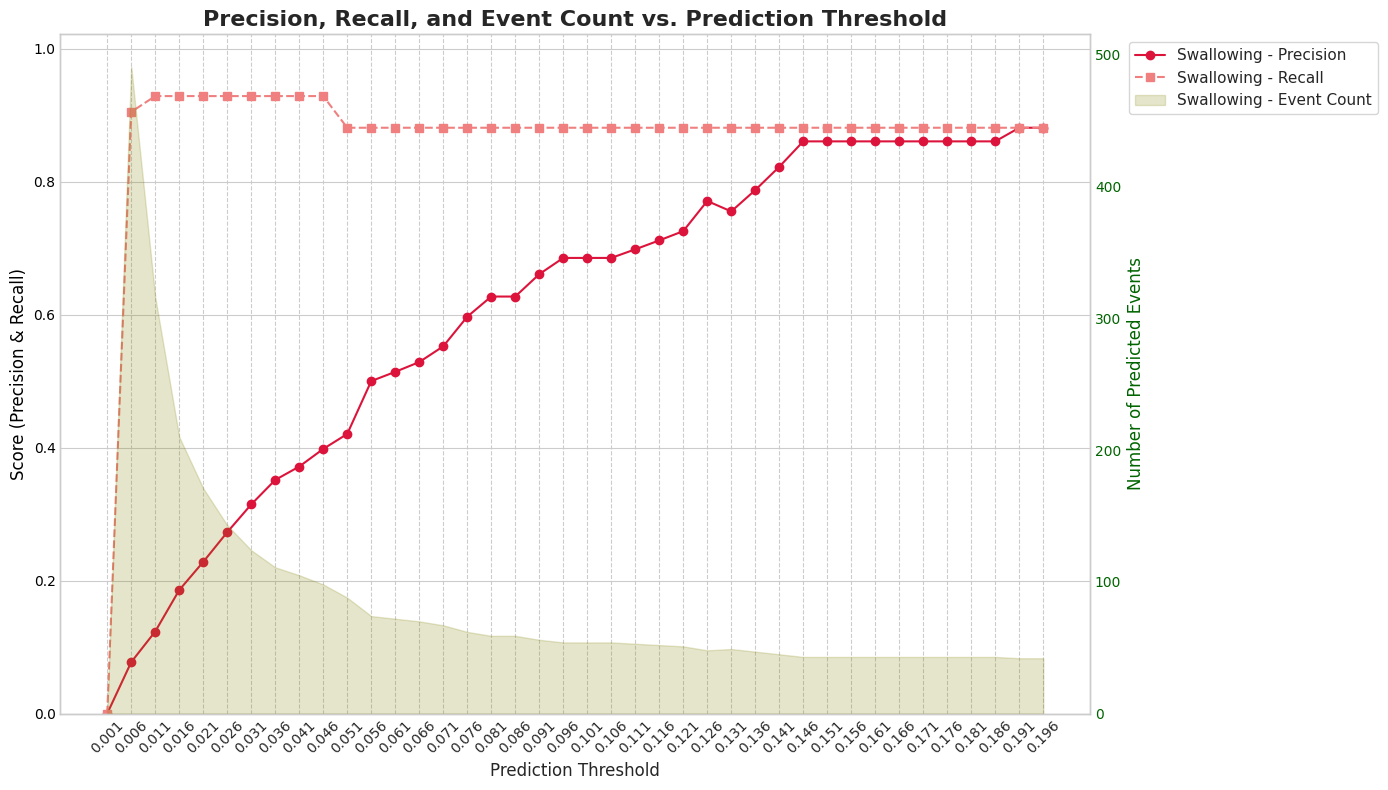

In [8]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Evaluation parameters
iou_thresholds = {
    "swallowing": 0.3
}
labels_to_evaluate = {
    "swallowing": "sw"
}

# Time window for evaluation (in seconds)
EVAL_START_SEC = 10 * 60  # 10 minutes
EVAL_END_SEC = 30 * 60    # 30 minutes

# --- 2. Utility Functions (Unchanged) ---

def convert_to_segments(binary_series: np.ndarray, times: np.ndarray) -> list:
    segments = []
    in_segment = False
    start_time = 0.0
    padded_series = np.pad(binary_series, (0, 1), 'constant', constant_values=0)
    padded_times = np.pad(times, (0, 1), 'edge')

    for i, value in enumerate(padded_series):
        if value > 0 and not in_segment:
            in_segment = True
            start_time = padded_times[i]
        elif value == 0 and in_segment:
            in_segment = False
            end_time = padded_times[i]
            if start_time < end_time:
                segments.append((start_time, end_time))
    return segments

def calculate_iou(seg1: tuple, seg2: tuple) -> float:
    start1, end1 = seg1
    start2, end2 = seg2
    intersection_start = max(start1, start2)
    intersection_end = min(end1, end2)
    intersection = max(0, intersection_end - intersection_start)
    union = (end1 - start1) + (end2 - start2) - intersection
    return intersection / union if union > 0 else 0

def evaluate_performance(gt_segments: list, pred_segments: list, iou_threshold: float) -> tuple:
    if not gt_segments or not pred_segments:
        tp, fp, fn = 0, len(pred_segments), len(gt_segments)
    else:
        iou_matrix = np.zeros((len(gt_segments), len(pred_segments)))
        for i, gt_seg in enumerate(gt_segments):
            for j, pred_seg in enumerate(pred_segments):
                iou_matrix[i, j] = calculate_iou(gt_seg, pred_seg)
        matched_gt = np.zeros(len(gt_segments), dtype=bool)
        matched_pred = np.zeros(len(pred_segments), dtype=bool)
        potential_matches = np.where(iou_matrix >= iou_threshold)
        sorted_indices = np.argsort(iou_matrix[potential_matches])[::-1]
        for idx in sorted_indices:
            gt_idx, pred_idx = potential_matches[0][idx], potential_matches[1][idx]
            if not matched_gt[gt_idx] and not matched_pred[pred_idx]:
                matched_gt[gt_idx], matched_pred[pred_idx] = True, True
        tp = np.sum(matched_gt)
        fn = len(gt_segments) - tp
        fp = len(pred_segments) - tp
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    return precision, recall, f1_score, tp, fp, fn

# --- 3. Main Processing ---

try:
    pred_prob_data = pd.read_csv(prediction_prob_file, sep='\t')
    gt_data = pd.read_csv(ground_truth_file, sep='\t', header=None, names=['start_time', 'end_time', 'label'])
except FileNotFoundError as e:
    print(f"Error: Could not find file - {e.filename}")
    exit()

ground_truth_events = {}
for label_long, label_short in labels_to_evaluate.items():
    gt_segs_df = gt_data[gt_data['label'] == label_short]
    all_segments = list(zip(gt_segs_df['start_time'], gt_segs_df['end_time']))
    ground_truth_events[label_long] = [
        seg for seg in all_segments if seg[0] < EVAL_END_SEC and seg[1] > EVAL_START_SEC
    ]

thresholds = np.arange(0.001, 0.2, 0.005)
results = {label: {'precision': [], 'recall': [], 'pred_count': []} for label in labels_to_evaluate.keys()}

print("Calculating scores for each threshold...")
for threshold in thresholds:
    predicted_events = {}
    for label_long in labels_to_evaluate.keys():
        binary_series = (pred_prob_data[label_long] >= threshold).astype(int).values
        all_segments = convert_to_segments(binary_series, pred_prob_data['time'].values)
        predicted_events[label_long] = [
            seg for seg in all_segments if seg[0] < EVAL_END_SEC and seg[1] > EVAL_START_SEC
        ]
    
    for label_long in labels_to_evaluate.keys():
        gt_segs = ground_truth_events[label_long]
        pred_segs = predicted_events[label_long]
        iou_thresh = iou_thresholds[label_long]
        
        precision, recall, _, _, _, _ = evaluate_performance(gt_segs, pred_segs, iou_thresh)
        
        results[label_long]['precision'].append(precision)
        results[label_long]['recall'].append(recall)
        results[label_long]['pred_count'].append(len(pred_segs))

print("Calculation complete. Plotting graph...")

# --- 4. Plotting ---
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax1 = plt.subplots(figsize=(14, 8))

# --- Left Y-axis (ax1) for Precision & Recall ---
ax1.set_xlabel('Prediction Threshold', fontsize=12)
ax1.set_ylabel('Score (Precision & Recall)', fontsize=12, color='black')
ax1.tick_params(axis='y', labelcolor='black')
ax1.set_xticks(thresholds)
ax1.tick_params(axis='x', rotation=45)

ax1.plot(thresholds, results['swallowing']['precision'], 'o-', label='Swallowing - Precision', color='crimson')
ax1.plot(thresholds, results['swallowing']['recall'], 's--', label='Swallowing - Recall', color='lightcoral')

all_scores = []
for label_data in results.values():
    all_scores.extend(label_data['precision'])
    all_scores.extend(label_data['recall'])
if all_scores:
    min_score, max_score = min(all_scores), max(all_scores)
    padding = (max_score - min_score) * 0.1
    ax1.set_ylim(max(0.0, min_score - padding), min(1.05, max_score + padding))
else:
    ax1.set_ylim(0.0, 1.05)


# --- Right Y-axis (ax2) for Event Count ---
ax2 = ax1.twinx()
ax2.set_ylabel('Number of Predicted Events', fontsize=12, color='darkgreen')
ax2.tick_params(axis='y', labelcolor='darkgreen')

# ★★★ Change alpha from 0.3 to 0.2 to make it more transparent ★★★

ax2.fill_between(thresholds, results['swallowing']['pred_count'], 
                 label='Swallowing - Event Count', 
                 color='olive', 
                 alpha=0.2)

ax2.set_ylim(bottom=0)


# --- Overall Graph Adjustments ---
ax1.set_title('Precision, Recall, and Event Count vs. Prediction Threshold', fontsize=16, weight='bold')
ax1.grid(True, which='major', linestyle='--', axis='x')
ax2.grid(False)

# Combine legends and place outside
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, 
           loc='upper left', 
           bbox_to_anchor=(1.03, 1.0),
           fontsize=11,
           frameon=True)

fig.tight_layout()
plt.show()

Calculating scores for each threshold...
Calculation complete. Plotting graph...


/tmp/ipykernel_1342258/2777121185.py:146: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax1.set_ylim(max(0.0, min_score - padding), min(1.05, max_score + padding))


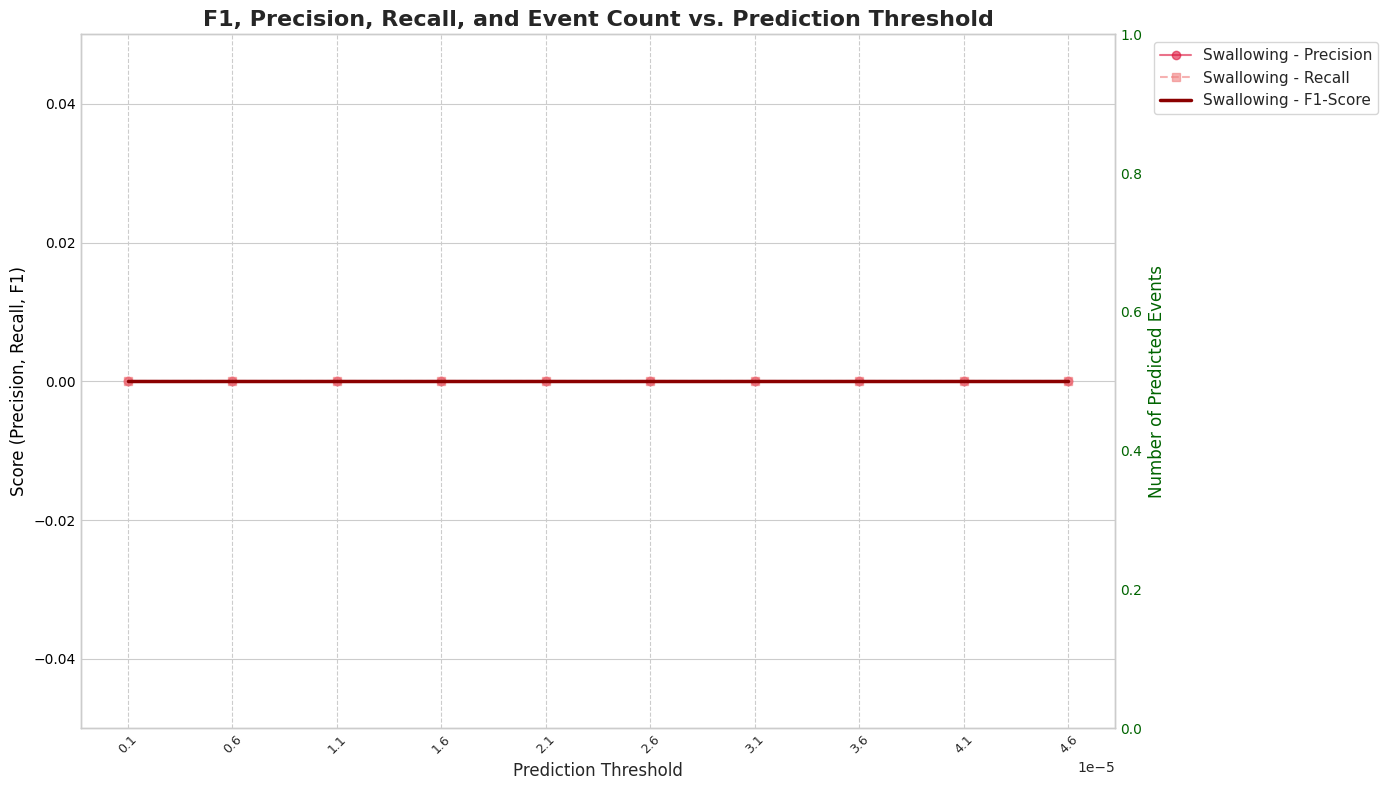

In [9]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Evaluation parameters
iou_thresholds = {
    "swallowing": 0.3
}
labels_to_evaluate = {
    "swallowing": "sw"
}

# Time window for evaluation (in seconds)
EVAL_START_SEC = 10 * 60  # 10 minutes
EVAL_END_SEC = 30 * 60    # 30 minutes

# --- 2. Utility Functions (Unchanged) ---

def convert_to_segments(binary_series: np.ndarray, times: np.ndarray) -> list:
    segments = []
    in_segment = False
    start_time = 0.0
    padded_series = np.pad(binary_series, (0, 1), 'constant', constant_values=0)
    padded_times = np.pad(times, (0, 1), 'edge')

    for i, value in enumerate(padded_series):
        if value > 0 and not in_segment:
            in_segment = True
            start_time = padded_times[i]
        elif value == 0 and in_segment:
            in_segment = False
            end_time = padded_times[i]
            if start_time < end_time:
                segments.append((start_time, end_time))
    return segments

def calculate_iou(seg1: tuple, seg2: tuple) -> float:
    start1, end1 = seg1
    start2, end2 = seg2
    intersection_start = max(start1, start2)
    intersection_end = min(end1, end2)
    intersection = max(0, intersection_end - intersection_start)
    union = (end1 - start1) + (end2 - start2) - intersection
    return intersection / union if union > 0 else 0

def evaluate_performance(gt_segments: list, pred_segments: list, iou_threshold: float) -> tuple:
    if not gt_segments or not pred_segments:
        tp, fp, fn = 0, len(pred_segments), len(gt_segments)
    else:
        iou_matrix = np.zeros((len(gt_segments), len(pred_segments)))
        for i, gt_seg in enumerate(gt_segments):
            for j, pred_seg in enumerate(pred_segments):
                iou_matrix[i, j] = calculate_iou(gt_seg, pred_seg)
        matched_gt = np.zeros(len(gt_segments), dtype=bool)
        matched_pred = np.zeros(len(pred_segments), dtype=bool)
        potential_matches = np.where(iou_matrix >= iou_threshold)
        sorted_indices = np.argsort(iou_matrix[potential_matches])[::-1]
        for idx in sorted_indices:
            gt_idx, pred_idx = potential_matches[0][idx], potential_matches[1][idx]
            if not matched_gt[gt_idx] and not matched_pred[pred_idx]:
                matched_gt[gt_idx], matched_pred[pred_idx] = True, True
        tp = np.sum(matched_gt)
        fn = len(gt_segments) - tp
        fp = len(pred_segments) - tp
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    return precision, recall, f1_score, tp, fp, fn

# --- 3. Main Processing ---

try:
    pred_prob_data = pd.read_csv(prediction_prob_file, sep='\t')
    gt_data = pd.read_csv(ground_truth_file, sep='\t', header=None, names=['start_time', 'end_time', 'label'])
except FileNotFoundError as e:
    print(f"Error: Could not find file - {e.filename}")
    exit()

ground_truth_events = {}
for label_long, label_short in labels_to_evaluate.items():
    gt_segs_df = gt_data[gt_data['label'] == label_short]
    all_segments = list(zip(gt_segs_df['start_time'], gt_segs_df['end_time']))
    ground_truth_events[label_long] = [
        seg for seg in all_segments if seg[0] < EVAL_END_SEC and seg[1] > EVAL_START_SEC
    ]

# ★★★ `f1_score` を保存するよう results 辞書を拡張 ★★★
thresholds = np.arange(0.000001, 0.00005, 0.000005)
results = {label: {'precision': [], 'recall': [], 'f1_score': [], 'pred_count': []} for label in labels_to_evaluate.keys()}

print("Calculating scores for each threshold...")
for threshold in thresholds:
    
    predicted_events = {}
    for label_long in labels_to_evaluate.keys():
        binary_series = (pred_prob_data[label_long] >= threshold).astype(int).values
        all_segments = convert_to_segments(binary_series, pred_prob_data['time'].values)
        predicted_events[label_long] = [
            seg for seg in all_segments if seg[0] < EVAL_END_SEC and seg[1] > EVAL_START_SEC
        ]
    
    for label_long in labels_to_evaluate.keys():
        gt_segs = ground_truth_events[label_long]
        pred_segs = predicted_events[label_long]
        iou_thresh = iou_thresholds[label_long]
        
        # ★★★ f1_score も受け取る ★★★
        precision, recall, f1_score, _, _, _ = evaluate_performance(gt_segs, pred_segs, iou_thresh)
        
        results[label_long]['precision'].append(precision)
        results[label_long]['recall'].append(recall)
        results[label_long]['f1_score'].append(f1_score) # ★★★ F1スコアを保存 ★★★
        results[label_long]['pred_count'].append(len(pred_segs))

print("Calculation complete. Plotting graph...")

# --- 4. Plotting ---
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax1 = plt.subplots(figsize=(14, 8))

# --- Left Y-axis (ax1) for Precision, Recall, and F1-score ---
ax1.set_xlabel('Prediction Threshold', fontsize=12)
ax1.set_ylabel('Score (Precision, Recall, F1)', fontsize=12, color='black')
ax1.tick_params(axis='y', labelcolor='black')
ax1.set_xticks(thresholds)
ax1.tick_params(axis='x', rotation=45, labelsize=9)

# P-R for Swallowing
ax1.plot(thresholds, results['swallowing']['precision'], 'o-', label='Swallowing - Precision', color='crimson', alpha=0.6)
ax1.plot(thresholds, results['swallowing']['recall'], 's--', label='Swallowing - Recall', color='lightcoral', alpha=0.6)

# ★★★ F1-scoreを太い実線でプロット ★★★
ax1.plot(thresholds, results['swallowing']['f1_score'], label='Swallowing - F1-Score', color='darkred', lw=2.5, zorder=10)


# Y-axis auto-adjustment
all_scores = []
for label_data in results.values():
    all_scores.extend(label_data['precision'])
    all_scores.extend(label_data['recall'])
    all_scores.extend(label_data['f1_score']) # ★★★ F1スコアも範囲計算に含める ★★★
if all_scores:
    min_score, max_score = min(all_scores), max(all_scores)
    padding = (max_score - min_score) * 0.1
    ax1.set_ylim(max(0.0, min_score - padding), min(1.05, max_score + padding))
else:
    ax1.set_ylim(0.0, 1.05)


# --- Right Y-axis (ax2) for Event Count ---
ax2 = ax1.twinx()
ax2.set_ylabel('Number of Predicted Events', fontsize=12, color='darkgreen')
ax2.tick_params(axis='y', labelcolor='darkgreen')
ax2.set_ylim(bottom=0)

# --- Overall Graph Adjustments ---
ax1.set_title('F1, Precision, Recall, and Event Count vs. Prediction Threshold', fontsize=16, weight='bold')
ax1.grid(True, which='major', linestyle='--', axis='x')
ax2.grid(False)

# Combine legends and place outside
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, 
           loc='upper left', 
           bbox_to_anchor=(1.03, 1.0),
           fontsize=11,
           frameon=True)

fig.tight_layout()
plt.show()

In [10]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Evaluation parameters
labels_to_evaluate = {
    "swallowing": "sw"
}

# Time window for evaluation (in seconds)
EVAL_START_SEC = 10 * 60  # 10 minutes
EVAL_END_SEC = 30 * 60    # 30 minutes

# 使用する閾値
threshold = 0.5

# IoUの評価範囲 - 重複がないように配列を作成
iou_ranges = np.round(np.arange(0.0, 1.01, 0.1), 2)  # 0.0から1.0までの範囲を明示的に指定

# --- Utility Functions ---
def convert_to_segments(binary_series: np.ndarray, times: np.ndarray) -> list:
    segments = []
    in_segment = False
    start_time = 0.0
    padded_series = np.pad(binary_series, (0, 1), 'constant', constant_values=0)
    padded_times = np.pad(times, (0, 1), 'edge')

    for i, value in enumerate(padded_series):
        if value > 0 and not in_segment:
            in_segment = True
            start_time = padded_times[i]
        elif value == 0 and in_segment:
            in_segment = False
            end_time = padded_times[i]
            if start_time < end_time:
                segments.append((start_time, end_time))
    return segments

def calculate_iou(seg1: tuple, seg2: tuple) -> float:
    start1, end1 = seg1
    start2, end2 = seg2
    intersection_start = max(start1, start2)
    intersection_end = min(end1, end2)
    intersection = max(0, intersection_end - intersection_start)
    union = (end1 - start1) + (end2 - start2) - intersection
    return intersection / union if union > 0 else 0

def evaluate_performance(gt_segments: list, pred_segments: list, iou_threshold: float) -> tuple:
    if not gt_segments or not pred_segments:
        tp, fp, fn = 0, len(pred_segments), len(gt_segments)
    else:
        iou_matrix = np.zeros((len(gt_segments), len(pred_segments)))
        for i, gt_seg in enumerate(gt_segments):
            for j, pred_seg in enumerate(pred_segments):
                iou_matrix[i, j] = calculate_iou(gt_seg, pred_seg)
        matched_gt = np.zeros(len(gt_segments), dtype=bool)
        matched_pred = np.zeros(len(pred_segments), dtype=bool)
        potential_matches = np.where(iou_matrix >= iou_threshold)
        sorted_indices = np.argsort(iou_matrix[potential_matches])[::-1]
        for idx in sorted_indices:
            gt_idx, pred_idx = potential_matches[0][idx], potential_matches[1][idx]
            if not matched_gt[gt_idx] and not matched_pred[pred_idx]:
                matched_gt[gt_idx], matched_pred[pred_idx] = True, True
        tp = np.sum(matched_gt)
        fn = len(gt_segments) - tp
        fp = len(pred_segments) - tp
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    return precision, recall, f1_score, tp, fp, fn

# --- データの読み込み ---
try:
    pred_prob_data = pd.read_csv(prediction_prob_file, sep='\t')
    gt_data = pd.read_csv(ground_truth_file, sep='\t', header=None, names=['start_time', 'end_time', 'label'])
except FileNotFoundError as e:
    print(f"Error: Could not find file - {e.filename}")
    exit()

# 正解データをセグメントに変換
ground_truth_events = {}
for label_long, label_short in labels_to_evaluate.items():
    gt_segs_df = gt_data[gt_data['label'] == label_short]
    all_segments = list(zip(gt_segs_df['start_time'], gt_segs_df['end_time']))
    ground_truth_events[label_long] = [
        seg for seg in all_segments if seg[0] < EVAL_END_SEC and seg[1] > EVAL_START_SEC
    ]

# 閾値0.5での予測を生成
predicted_events = {}
for label_long in labels_to_evaluate.keys():
    binary_series = (pred_prob_data[label_long] >= threshold).astype(int).values
    all_segments = convert_to_segments(binary_series, pred_prob_data['time'].values)
    predicted_events[label_long] = [
        seg for seg in all_segments if seg[0] < EVAL_END_SEC and seg[1] > EVAL_START_SEC
    ]

# --- IoU別の評価結果を計算 ---
# 各タイプのデータについて別々に処理
for label_long in labels_to_evaluate.keys():
    print(f"[INFO] {label_long}:")
    gt_segs = ground_truth_events[label_long]
    pred_segs = predicted_events[label_long]
    
    # 各IoU閾値ごとに評価
    for iou_thresh in iou_ranges:
        precision, recall, f1_score, _, _, _ = evaluate_performance(gt_segs, pred_segs, iou_thresh)
        print(f"[INFO]   IoU > {iou_thresh:.2f}: P={precision:.3f}, R={recall:.3f}, F1={f1_score:.3f}")
    
    # 視覚的な区切りを追加
    if label_long != list(labels_to_evaluate.keys())[-1]:
        print()  # 空行を追加して読みやすく

[INFO] swallowing:
[INFO]   IoU > 0.00: P=1.000, R=0.929, F1=0.963
[INFO]   IoU > 0.10: P=0.923, R=0.857, F1=0.889
[INFO]   IoU > 0.20: P=0.923, R=0.857, F1=0.889
[INFO]   IoU > 0.30: P=0.923, R=0.857, F1=0.889
[INFO]   IoU > 0.40: P=0.923, R=0.857, F1=0.889
[INFO]   IoU > 0.50: P=0.897, R=0.833, F1=0.864
[INFO]   IoU > 0.60: P=0.846, R=0.786, F1=0.815
[INFO]   IoU > 0.70: P=0.692, R=0.643, F1=0.667
[INFO]   IoU > 0.80: P=0.333, R=0.310, F1=0.321
[INFO]   IoU > 0.90: P=0.077, R=0.071, F1=0.074
[INFO]   IoU > 1.00: P=0.026, R=0.024, F1=0.025
